# BDGDM subtype comparison

This notebook demonstrates how to compare CN–expression responses between tumour subtypes using the BDGDM hierarchical subtype model.
The analysis uses tumour samples only. Matched normal samples are not required.

## Input data

BDGDM expects one row per sample and gene, with the following variables:

| Column | Description |
|---|---|
| `sampleID` | Unique tumour-sample identifier |
| `gene` | Gene identifier |
| `expr` | Raw RNA-seq count |
| `copies` | Absolute copy number |
| `purity` | Tumour purity between 0 and 1 |
| `sf` | RNA-seq size factor |
| `subtype` | Tumour subtype, for example MSS or MSI |

Edit the column-name configuration below when your dataset uses different names.

In [3]:
from __future__ import annotations

import inspect
import platform
from pathlib import Path
from importlib.resources import files

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel

import bdgdm
from bdgdm import  BDGDMConfig, load_example_data, fit_one_gene_bdgdm
from bdgdm.posterior import  get_posterior_summary_subtype
from bdgdm.diagnostics import  get_nuts_diagnostics
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.classify import ClassificationThresholds, classify_fit, get_subtype_classification,  get_transition_classification, get_transition_df, classification_to_rewiring_df
from bdgdm.plot_fit import plot_ppc_density

import arviz as az
import xarray as xr

## Load the example dataset

The example dataset is distributed with BDGDM so that the tutorial can be executed without downloading external data.

In [6]:
data = load_example_data()

print("Rows:", len(data))
print("Genes:", data["gene"].nunique())
print("Samples:", data["sampleID"].nunique())

data.head()

Rows: 104516
Genes: 106
Samples: 986


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


## Choose the subtypes

The requested labels are used when available. Otherwise, the two most frequent subtypes are selected.

In [9]:
SELECTED_SUBTYPES = ("MSI", "MSS")
COLUMN_MAP = {
    "gene": "gene",
    "sample": "sampleID",
    "expression": "expr",
    "copy_number": "copies",
    "subtype": "subtype",
    "purity": "purity",
    "size_factor": "sf"
}

MIN_SAMPLES_PER_SUBTYPE = 20
MIN_CN_STATES_PER_SUBTYPE = 2
MIN_ALTERED_PER_SUBTYPE = 5
MIN_MEDIAN_EXPRESSION = 10

subtype_col = COLUMN_MAP["subtype"]
available_subtypes = data[subtype_col].dropna().astype(str).value_counts()
requested = [str(value) for value in SELECTED_SUBTYPES]

if all(value in available_subtypes.index for value in requested):
    selected_subtypes = tuple(requested)
else:
    if len(available_subtypes) < 2:
        raise ValueError("At least two subtype levels are required.")
    selected_subtypes = tuple(available_subtypes.index[:2])
    print("Using the two most frequent subtypes:", selected_subtypes)

(
    data.loc[data[subtype_col].isin(selected_subtypes)]
    .groupby(subtype_col)[COLUMN_MAP["sample"]]
    .nunique()
    .rename("n_samples")
)

subtype
MSI    208
MSS    778
Name: n_samples, dtype: int64

## Select an informative gene in every subtype

A gene can be variable in one subtype and nearly diploid in another. We rank by the **minimum** CN entropy and standard deviation across the selected subtypes so that both subtype-specific responses are estimable.

In [12]:
def copy_number_entropy(values: pd.Series) -> float:
    probabilities = values.value_counts(normalize=True).to_numpy(dtype=float)
    return float(-np.sum(probabilities * np.log2(probabilities)))


analysis_data = data.loc[data[subtype_col].isin(selected_subtypes)].copy()
analysis_data["is_altered"] = analysis_data[COLUMN_MAP["copy_number"]].ne(2)

cn_by_subtype = (
    analysis_data
    .groupby([COLUMN_MAP["gene"], subtype_col], as_index=False)
    .agg(
        n_samples=(COLUMN_MAP["sample"], "nunique"),
        cn_sd=(COLUMN_MAP["copy_number"], "std"),
        cn_range=(COLUMN_MAP["copy_number"], lambda x: x.max() - x.min()),
        cn_entropy=(COLUMN_MAP["copy_number"], copy_number_entropy),
        n_cn_states=(COLUMN_MAP["copy_number"], "nunique"),
        n_altered=("is_altered", "sum"),
        altered_fraction=("is_altered", "mean"),
        median_expr=(COLUMN_MAP["expression"], "median"),
    )
)

eligible = cn_by_subtype.loc[
    cn_by_subtype["n_samples"].ge(MIN_SAMPLES_PER_SUBTYPE)
    & cn_by_subtype["n_cn_states"].ge(MIN_CN_STATES_PER_SUBTYPE)
    & cn_by_subtype["n_altered"].ge(MIN_ALTERED_PER_SUBTYPE)
    & cn_by_subtype["median_expr"].ge(MIN_MEDIAN_EXPRESSION)
].copy()

gene_rank = (
    eligible
    .groupby(COLUMN_MAP["gene"], as_index=False)
    .agg(
        n_subtypes=(subtype_col, "nunique"),
        minimum_cn_entropy=("cn_entropy", "min"),
        minimum_cn_sd=("cn_sd", "min"),
        minimum_cn_states=("n_cn_states", "min"),
        minimum_altered_samples=("n_altered", "min"),
        total_samples=("n_samples", "sum"),
    )
    .loc[lambda x: x["n_subtypes"].eq(len(selected_subtypes))]
    .sort_values(
        ["minimum_cn_entropy", "minimum_cn_sd", "minimum_altered_samples"],
        ascending=False,
    )
    .reset_index(drop=True)
)

if gene_rank.empty:
    raise ValueError(
        "No gene passed the subtype-specific CN coverage requirements."
    )

gene_rank.head(10)

,gene,n_subtypes,minimum_cn_entropy,minimum_cn_sd,minimum_cn_states,minimum_altered_samples,total_samples
0,TRPS1,2,0.468120,0.291677,3,19,986
1,BRAF,2,0.417189,0.291677,3,16,986
2,FZD3,2,0.406249,0.257189,3,14,986
3,FOXP2,2,0.380782,0.277308,3,14,986
4,KLF5,2,0.380782,0.253552,3,14,986
5,SKA3,2,0.380782,0.253552,3,14,986
6,SLC46A3,2,0.380782,0.253552,3,14,986
7,CYP7B1,2,0.355795,0.251159,2,14,986
8,RBBP7,2,0.351095,0.230471,3,11,986
9,CDKN2A,2,0.334702,0.228040,3,11,986


In [14]:
gene = "KLF5"

gene_df = (
    analysis_data.loc[
        analysis_data[COLUMN_MAP["gene"]].astype(str).eq(gene)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Selected gene:", gene)
print("Subtypes:", selected_subtypes)
print("Samples:", len(gene_df))

Selected gene: KLF5
Subtypes: ('MSI', 'MSS')
Samples: 986


## Inspect CN-state coverage

A comparison is difficult to interpret when subtype and CN state are strongly confounded.

In [17]:
coverage_table = (
    gene_df
    .groupby([subtype_col, COLUMN_MAP["copy_number"]], as_index=False)
    .agg(
        n_samples=(COLUMN_MAP["sample"], "nunique"),
        median_expr=(COLUMN_MAP["expression"], "median"),
        mean_purity=(COLUMN_MAP["purity"], "mean"),
    )
)

coverage_pivot = coverage_table.pivot(
    index=subtype_col,
    columns=COLUMN_MAP["copy_number"],
    values="n_samples",
).fillna(0).astype(int)

coverage_pivot

copies,1,2,3,4,5,7
subtype,,,,,,
MSI,1,194,13,0,0,0
MSS,3,452,266,48,8,1


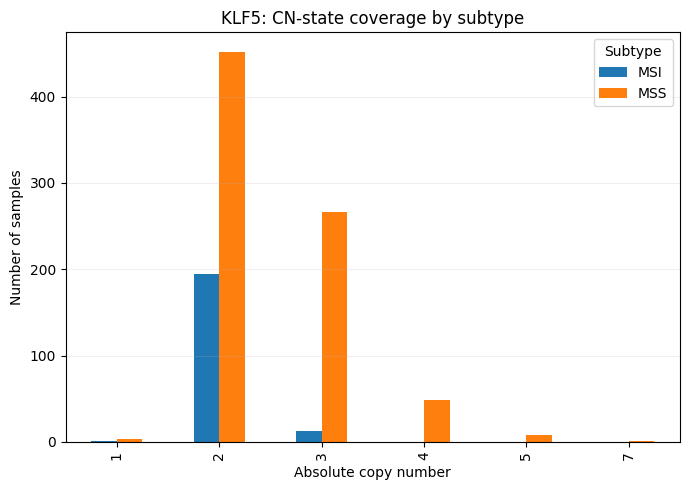

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
coverage_pivot.T.plot(kind="bar", ax=ax)
ax.set_xlabel("Absolute copy number")
ax.set_ylabel("Number of samples")
ax.set_title(f"{gene}: CN-state coverage by subtype")
ax.legend(title="Subtype")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()

## Exploratory expression–CN relationship

This descriptive plot does not adjust for purity or negative-binomial uncertainty.

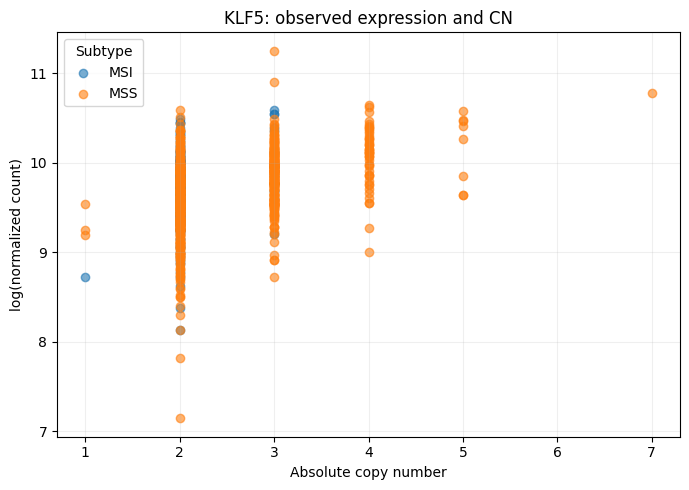

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

for subtype, subtype_df in gene_df.groupby(subtype_col):
    ax.scatter(
        subtype_df[COLUMN_MAP["copy_number"]],
        np.log1p(
            subtype_df[COLUMN_MAP["expression"]]
            / subtype_df[COLUMN_MAP["size_factor"]]
        ),
        alpha=0.6,
        label=subtype,
    )

ax.set_xlabel("Absolute copy number")
ax.set_ylabel("log(normalized count)")
ax.set_title(f"{gene}: observed expression and CN")
ax.legend(title="Subtype")
ax.grid(alpha=0.2)
fig.tight_layout()

## Fit BDGDM subtype model

In [25]:
# Configure the fit
config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.95,
    return_ppc=True,
    save_draws=False,
    save_summary=False,
    seed=123
)

In [27]:
# Run BDGDM

stan_dir = files("bdgdm").joinpath("stan")

model_single = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_single.stan")
    )
)

model_subtype = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_subtype.stan")
    )
)

fit = fit_one_gene_bdgdm(
    gene_df=gene_df,
    gene="KLF5",
    model_single=model_single,
    model_subtype=model_subtype,
    cna="all",
    config=config,
)

12:22:37 - cmdstanpy - INFO - CmdStan start processing
12:22:37 - cmdstanpy - INFO - Chain [1] start processing
12:22:37 - cmdstanpy - INFO - Chain [2] start processing
12:22:37 - cmdstanpy - INFO - Chain [3] start processing
12:22:37 - cmdstanpy - INFO - Chain [4] start processing
12:23:38 - cmdstanpy - INFO - Chain [3] done processing
12:23:41 - cmdstanpy - INFO - Chain [1] done processing
12:23:41 - cmdstanpy - INFO - Chain [4] done processing
12:23:44 - cmdstanpy - INFO - Chain [2] done processing


## Posterior parameter estimates

In [30]:
posterior_summary = fit.posterior
metadata_df, parameter_summary, transition_summary, contrast_summary = get_posterior_summary_subtype(posterior_summary)

display(metadata_df)
display(parameter_summary.round(3))
display(transition_summary.round(3))
display(contrast_summary.round(3))

,gene,analysis_mode,engine,n_subtypes,subtype_levels,subtype_levels_str,subtype_1,subtype_2
0,None,subtype_comparison,nuts,2,"[MSI, MSS]",MSI|MSS,MSI,MSS


,parameter,parameter_scope,subtype_index,subtype,median,q025,q975,p_rope
0,b_noncancer_log,shared,NaN,None,1.675,0.593,2.707,NaN
1,phi,shared,NaN,None,4.908,4.512,5.331,NaN
2,b0,subtype,1.0,MSI,10.620,10.557,10.683,NaN
3,b_scaling,subtype,1.0,MSI,0.678,0.015,1.354,NaN
4,b_deviation,subtype,1.0,MSI,-0.127,-0.644,0.360,0.273
5,b0,subtype,2.0,MSS,10.513,10.473,10.552,NaN
6,b_scaling,subtype,2.0,MSS,0.602,0.100,1.106,NaN
7,b_deviation,subtype,2.0,MSS,-0.204,-0.565,0.162,0.230


,subtype_index,subtype,transition,transition_key,lp_median,lp_q025,lp_q975,fractional_change_median,fractional_change_q025,fractional_change_q975,...,ppd,scaling_component_median,scaling_component_q025,scaling_component_q975,deviation_component_median,deviation_component_q025,deviation_component_q975,cancellation_index_median,cancellation_index_q025,cancellation_index_q975
0,1,MSI,2→1,2to1,-0.405,-0.766,-0.041,-0.333,-0.535,-0.041,...,0.987,-0.470,-0.939,-0.011,0.064,-0.180,0.322,0.138,-1.935,0.591
1,1,MSI,2→3,2to3,0.209,-0.008,0.433,0.233,-0.008,0.542,...,0.968,0.275,0.006,0.549,-0.064,-0.322,0.180,-0.236,-1.011,3.307
2,1,MSI,2→4,2to4,0.338,-0.064,0.759,0.402,-0.062,1.135,...,0.951,0.470,0.011,0.939,-0.127,-0.644,0.360,-0.276,-1.183,3.869
3,2,MSS,2→1,2to1,-0.315,-0.499,-0.140,-0.270,-0.393,-0.130,...,1.000,-0.418,-0.766,-0.069,0.102,-0.081,0.282,0.244,-1.124,0.390
4,2,MSS,2→3,2to3,0.142,0.088,0.197,0.153,0.092,0.217,...,1.000,0.244,0.041,0.448,-0.102,-0.282,0.081,-0.418,-0.666,1.922
5,2,MSS,2→4,2to4,0.214,0.125,0.307,0.238,0.133,0.359,...,1.000,0.418,0.069,0.766,-0.204,-0.565,0.162,-0.489,-0.779,2.249


,contrast,contrast_prefix,subtype_1,subtype_2,median,q025,q975,ppd,p_rope
0,baseline_expression,tumor0_lfc,MSI,MSS,-0.153,-0.263,-0.050,0.997,0.976
1,dosage_scaling,delta_scaling,MSI,MSS,-0.070,-0.696,0.532,0.590,0.244
2,deviation,delta_dev,MSI,MSS,-0.077,-0.507,0.375,0.637,0.322


## Model diagnostics

In [32]:
diagnostics = fit.diagnostics

diagnostic_checks = get_nuts_diagnostics(
    diagnostics
)

diagnostic_checks

,check,value,passed
0,Overall diagnostic status,ok,True
1,Convergence flag,True,True
2,Maximum core R-hat,1.00151,True
3,Minimum core bulk ESS,2525.39,True
4,Divergent transitions,0,True


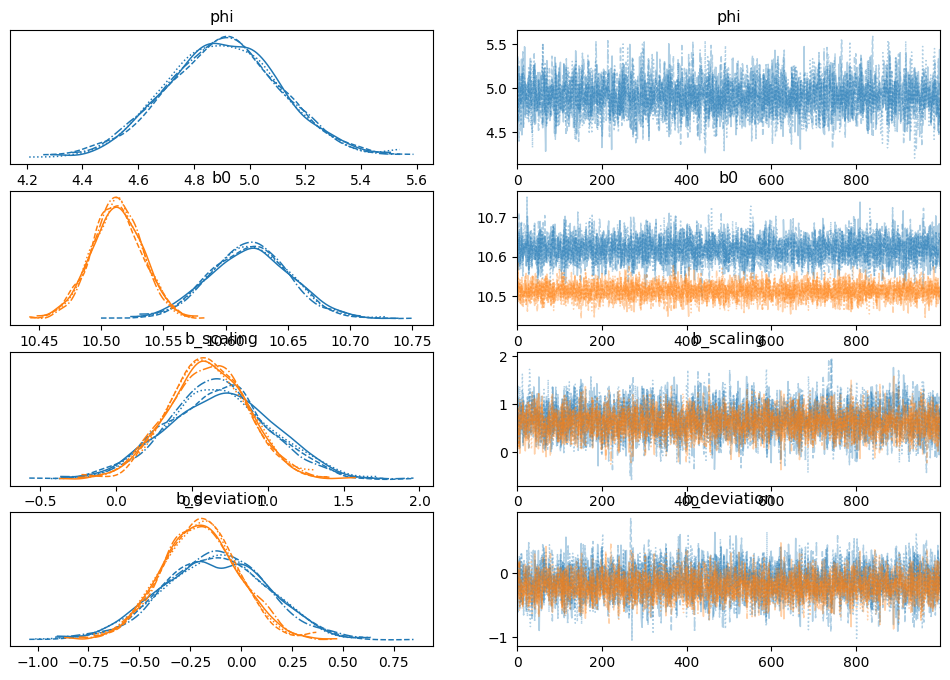

In [34]:
idata = az.from_cmdstanpy(posterior=fit.fit)
available = list(idata.posterior.data_vars)

az.plot_trace(
    idata,
    var_names=[
        "phi",
        "b0",
        "b_scaling",
        "b_deviation",
    ],
)

plt.show()

## Posterior predictive checks

Posterior predictive checks (PPCs) compare the observed counts with counts generated from the fitted model.

In [36]:
processed, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="KLF5",
    cna="all",
    et=0.15,
    min_aneup=5,
    min_unique_counts=5,
    min_cn_abs_sum=1.0,
)

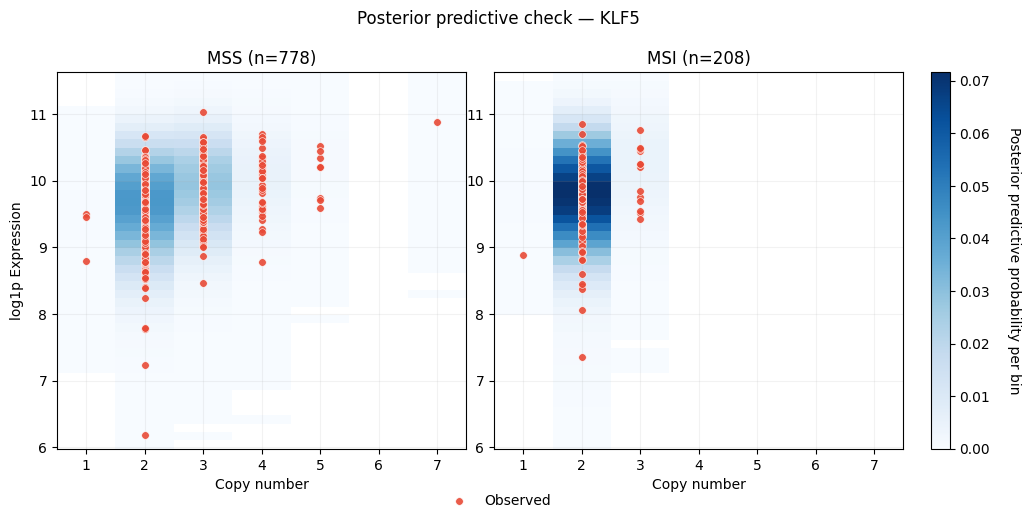

In [38]:
fig, axes, ppc_summary = plot_ppc_density(
    fit,
    x_observed=processed["copies"],
    y_observed=stan_data["y"],
    subtype_observed=processed["subtype"],
    subtype_order=["MSS", "MSI"],
    gene="KLF5",
    transform="log1p",
    x_bins="integer",
    density_mode="probability",
    figsize=(10.5, 5.7),
)

## Classify each subtype gene-dosage response

Classification combines posterior transition effects, directional probabilities, ROPE probabilities, and credible-interval support using predefined thresholds.

Possible outputs include:

- **DSG**: proportional CN–expression response;
- **DCG**: an attenuated response relative to proportional dosage scaling;
- **HYPER**: a response stronger than the proportional expectation;
- **Mixed**: different response patterns supported by different CN transitions;
- **UNC**: the posterior is valid, but the evidence is insufficient for a specific response class;
- **DIG**: little or no supported expression response to CN change.

In [41]:
# Define classification thresholds

thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=10,
)

In [43]:
# Classify
classif = classify_fit(fit,
                      thresholds=thresholds)

subtype1_result = get_subtype_classification(classif,
                                            subtype="MSS")
subtype1_result

{'gene': 'KLF5',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'subtype_comparison',
 'N': 986,
 'n_aneup': 340,
 'cna': 'all',
 'subtype_index': 2,
 'subtype': 'MSS',
 'response_class': 'DCG',
 'response_reason': 'supported_dcg_pattern',
 'response_subclass': None,
 'b_scaling_median': 0.6023535,
 'b_deviation_median': -0.20434400000000003,
 'p_deviation_small': 0.22975,
 'small_deviation': False,
 'small_deviation_method': 'posterior_probability',
 'dc_gain': True,
 'dc_loss': True,
 'dc_type': 'DC-bi'}

In [33]:
subtype2_result = get_subtype_classification(classif,
                                            subtype="MSI")
subtype2_result

{'gene': 'BRAF',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'subtype_comparison',
 'N': 986,
 'n_aneup': 139,
 'cna': 'all',
 'subtype_index': 1,
 'subtype': 'MSI',
 'response_class': 'DSG',
 'response_reason': 'supported_dsg_pattern',
 'response_subclass': None,
 'b_scaling_median': 0.767542,
 'b_deviation_median': 0.470231,
 'p_deviation_small': 0.056,
 'small_deviation': False,
 'small_deviation_method': 'posterior_probability',
 'dc_gain': False,
 'dc_loss': False,
 'dc_type': 'none'}

## Subtype-specific dosage-response rewiring

BDGDM evaluates whether the relationship between copy number and gene expression differs between tumour subtypes. This is referred to as
**dosage-response rewiring**.

The analysis considers two direct posterior contrasts:

- **Scaling contrast (`delta_scaling`)**: tests whether the strength of the CN–expression response differs between subtypes.
- **Deviation contrast (`delta_dev`)**: tests whether the deviation from the scaling response differs between subtypes.

Uor classifier defines a contrast as rewired when both PPD >= ppd_sig and P(ROPE) <= rope_low. When neither contrast is supported, the result is not_rewired only if both contrasts are confidently inside their ROPE; otherwise it is rewiring_uncertain.

Possible `rewiring_status` labels: 

| Status | Interpretation |
|---|---|
| `rewired:scaling` | The dosage-scaling response differs between subtypes. |
| `rewired:deviation` | The deviation component differs between subtypes. |
| `rewired:scaling+deviation` | Both scaling and deviation differ between subtypes. |
| `not_rewired` | Both contrasts support practical similarity. |
| `rewiring_uncertain` | Evidence is insufficient for either rewiring or similarity. |


In [46]:
rewiring_summary = (
    classification_to_rewiring_df(
        fit,
        thresholds=thresholds,
    )
)
display(rewiring_summary)

,gene,status,fit_flag,analysis_mode,n_subtypes,subtype_levels,subtype_levels_str,rewiring_status,scaling_rewired,deviation_rewired,...,delta_scaling_q025,delta_scaling_q975,ppd_scaling,p_rope_scaling,delta_dev_median,delta_dev_q025,delta_dev_q975,ppd_dev,p_rope_dev,summary_label
0,KLF5,ok,ok,subtype_comparison,2,"[MSI, MSS]",MSI|MSS,rewiring_uncertain,False,False,...,-0.695501,0.532249,0.59025,0.24425,-0.076938,-0.50657,0.375426,0.637,0.322,"DE-null | rewiring_uncertain | MSI:UNC,MSS:DCG"


In this analysis, all subtype contrasts are defined as **MSS − MSI**. Consequently, a positive contrast indicates a larger parameter value in
MSS, whereas a negative contrast indicates a larger value in MSI.